In [157]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

In [158]:
f = cv.imread("images/emma.jpg")
# cv.namedWindow('Image', cv.WINDOW_AUTOSIZE)
# cv.imshow('Image', f)
# cv.waitKey(0)
# cv.destroyAllWindows()


(256,)


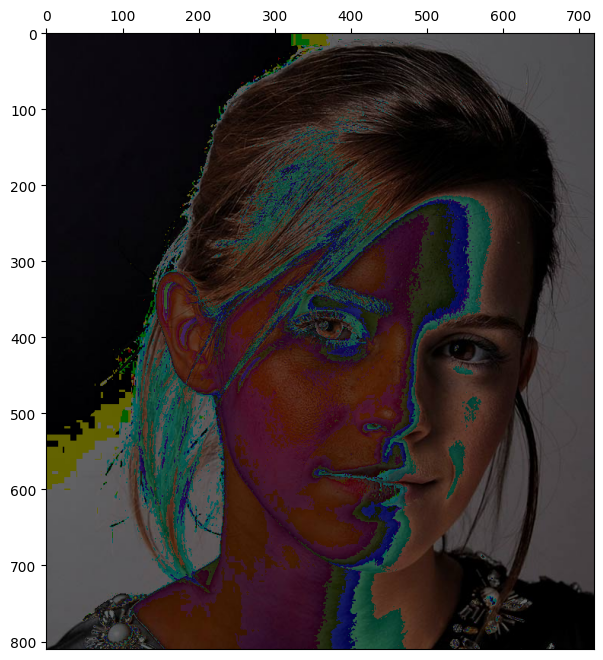

In [159]:
fig, ax = plt.subplots(1,1,figsize=(8,8))
t1 = np.arange(100, dtype=np.uint8)
t2 = np.arange(50, dtype=np.uint8)
t3 = np.arange(106, dtype=np.uint8)
t = np.concatenate((t1,t2,t3))
print(t.shape)
f = t[f]
ax.imshow(cv.cvtColor(f, cv.COLOR_BGR2RGB))
ax.xaxis.set_ticks_position('top')
plt.show()

(256,)


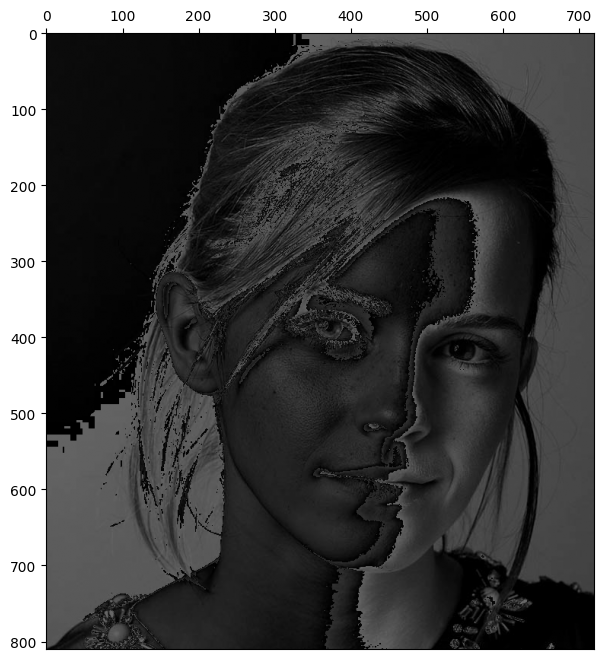

In [160]:
f = cv.imread("images/emma.jpg", cv.IMREAD_GRAYSCALE)
fig, ax = plt.subplots(1,1,figsize=(8,8))
t1 = np.arange(100, dtype=np.uint8)
t2 = np.arange(50, dtype=np.uint8)
t3 = np.arange(106, dtype=np.uint8)
t = np.concatenate((t1,t2,t3))
print(t.shape)
f = t[f]
ax.imshow(f, cmap='gray', vmin=0, vmax=255)
ax.xaxis.set_ticks_position('top')
plt.show()

In [161]:
def intensity_transform(im, breakpoints):
    # 1. Unpack your breakpoints into two separate arrays: x_coords (input) and y_coords (output).
    
    # 2. Use np.interp() to evaluate the original image pixels against your coordinates.
    # Concept: np.interp(im, x_coords, y_coords)
    
    # 3. The interpolation returns floats. Convert the array back to standard image format using .astype(np.uint8).
    
    # return the final_image
    return

[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49 100 101 102 104
 105 107 108 109 111 112 114 115 116 118 119 121 122 123 125 126 128 129
 130 132 133 135 136 137 139 140 142 143 144 146 147 149 150 151 153 154
 156 157 158 160 161 163 164 165 167 168 170 171 173 175 176 178 180 181
 183 185 187 188 190 192 193 195 197 198 200 202 204 205 207 209 210 212
 214 215 217 219 221 222 224 226 227 229 231 232 234 236 238 239 241 243
 244 246 248 249 251 253 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

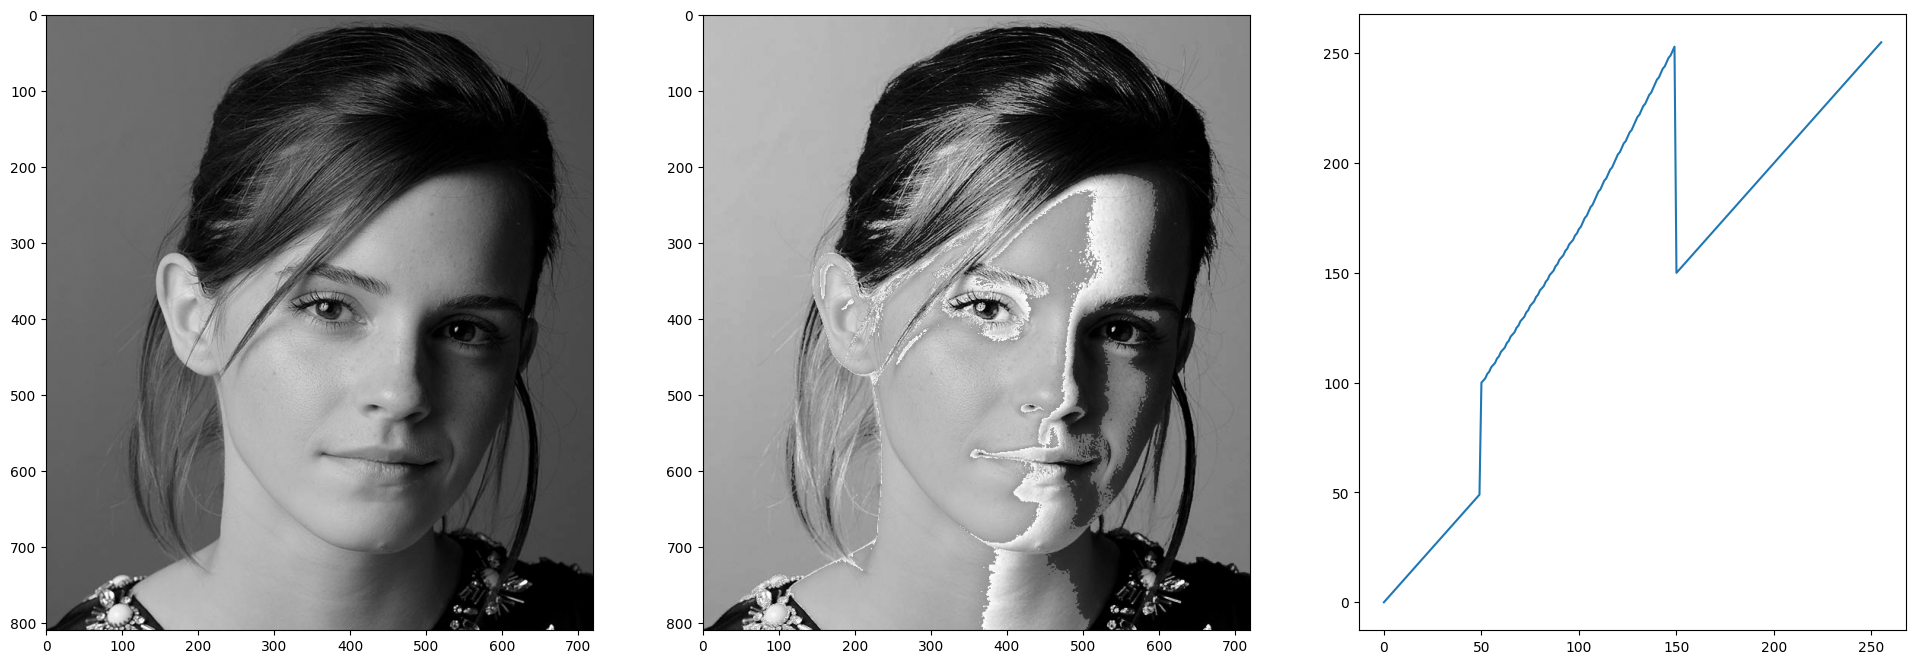

In [162]:
x = [0,50,50,100,150,150,255]
y = [0,50,100,170,255,150,255]
f = cv.imread("images/emma.jpg", cv.IMREAD_GRAYSCALE)
X = np.arange(256, dtype='uint8')
F = np.interp(X,x,y).astype(np.uint8)

print(F)
fig, axes = plt.subplots(1,3, figsize=(24,8))
axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[1].imshow(F[f], cmap='gray', vmin=0, vmax=255)
axes[2].plot(X,F)
plt.show()

#print(X_interp)

In [163]:
def intensity_transform(im, breakpoints):
    x, y = zip(*breakpoints) 
    X = np.arange(256, dtype='uint8')
    F = np.interp(X, x, y).astype(np.uint8)
    return F[im], X, F

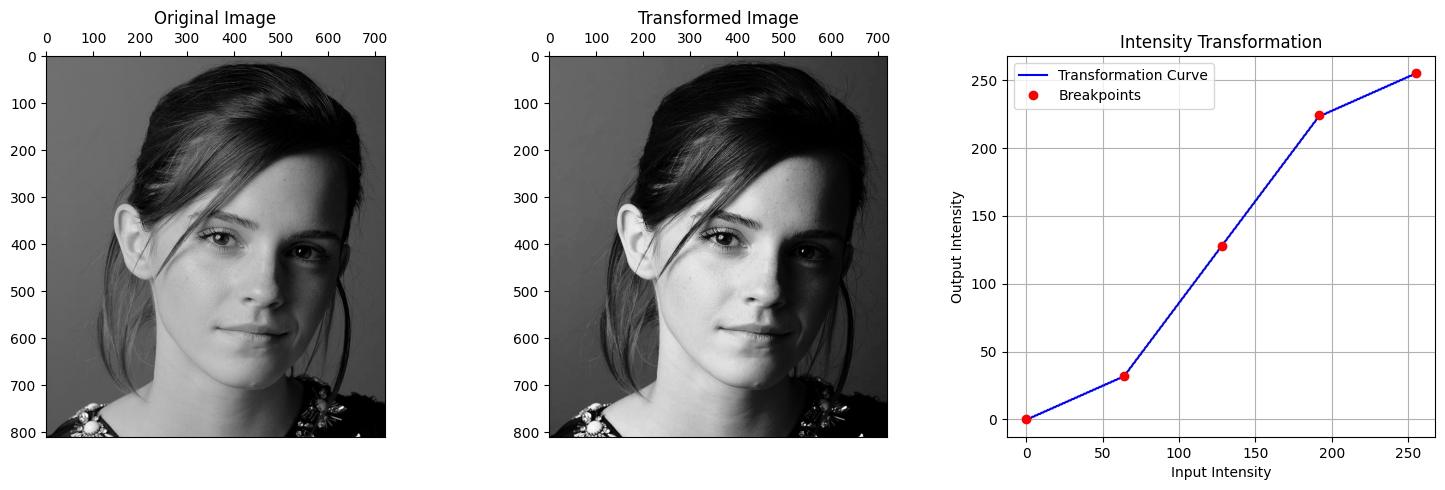

In [164]:
f = cv.imread("images/emma.jpg", cv.IMREAD_GRAYSCALE)

# 3. Experiment with breakpoints (S-curve for pleasing contrast enhancement)
breakpoints = [(0, 0), (64, 32), (128, 128), (192, 224), (255, 255)]

# 4. Apply the transformation
transformed_img, X, F = intensity_transform(f, breakpoints)

# 5. Display the original image, transformed image, and plot side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
 # Move x-axis ticks to the top for all subplots

# Original Image
axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].xaxis.set_ticks_position('top')  # Hides the axes ticks for a cleaner look

# Transformed Image
axes[1].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Transformed Image")
axes[1].xaxis.set_ticks_position('top')  # Hides the axes ticks for a cleaner look

# Transformation Plot
axes[2].plot(X, F, color='blue', label='Transformation Curve')
# Optionally plot the actual breakpoints as red dots for clarity
x_coords, y_coords = zip(*breakpoints)
axes[2].plot(x_coords, y_coords, 'ro', label='Breakpoints') 
axes[2].set_title("Intensity Transformation")
axes[2].set_xlabel("Input Intensity")
axes[2].set_ylabel("Output Intensity")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

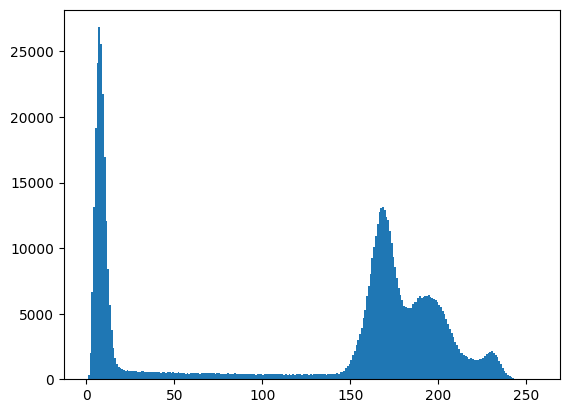

Intensity 140: 1.5274000670565884
Intensity 141: 1.5124986029877436
Intensity 142: 1.8403308125023283
Intensity 143: 1.6130834854524456
Intensity 144: 1.9595425250530865
Intensity 145: 2.1122825317587455
Intensity 146: 2.4363893752561188
Intensity 147: 3.1069552583541333
Intensity 148: 3.7886972395037812
Intensity 149: 4.444361658532951
Intensity 150: 5.558246097679097
Intensity 151: 7.0111388443914615
Intensity 152: 8.046790597176173
Intensity 153: 9.659874082628619
Intensity 154: 11.187274149685207
Intensity 155: 12.755653242931118
Intensity 156: 14.644413813657192
Intensity 157: 17.434712960548374
Intensity 158: 19.666207204857876
Intensity 159: 23.782736653876242
Intensity 160: 26.632641657042804
Intensity 161: 29.92959058227471
Intensity 162: 34.418656633014194
Intensity 163: 37.43992847297247
Intensity 164: 40.56923592742987
Intensity 165: 44.08970681369445
Intensity 166: 47.509592817494315
Intensity 167: 48.7687665313117
Intensity 168: 49.036992884550905
Intensity 169: 48.217412

In [165]:
brain_img = cv.imread("images/brain.png", cv.IMREAD_GRAYSCALE)

# Compute histogram
hist_values, bin_edges, _ = plt.hist(brain_img.ravel(), bins=256, range=[0,256])

plt.show()

# Print histogram values
for intensity in range(140,256):
    print(f"Intensity {intensity}: {100*hist_values[intensity]/np.max(hist_values)}")

[[ 2  4  6 ... 10 12 11]
 [ 4  5  7 ... 10 11 11]
 [ 6  7  8 ...  9 10 10]
 ...
 [ 8  9  9 ...  4  4  4]
 [ 8  9  9 ...  4  4  4]
 [ 9  9  9 ...  4  4  4]]


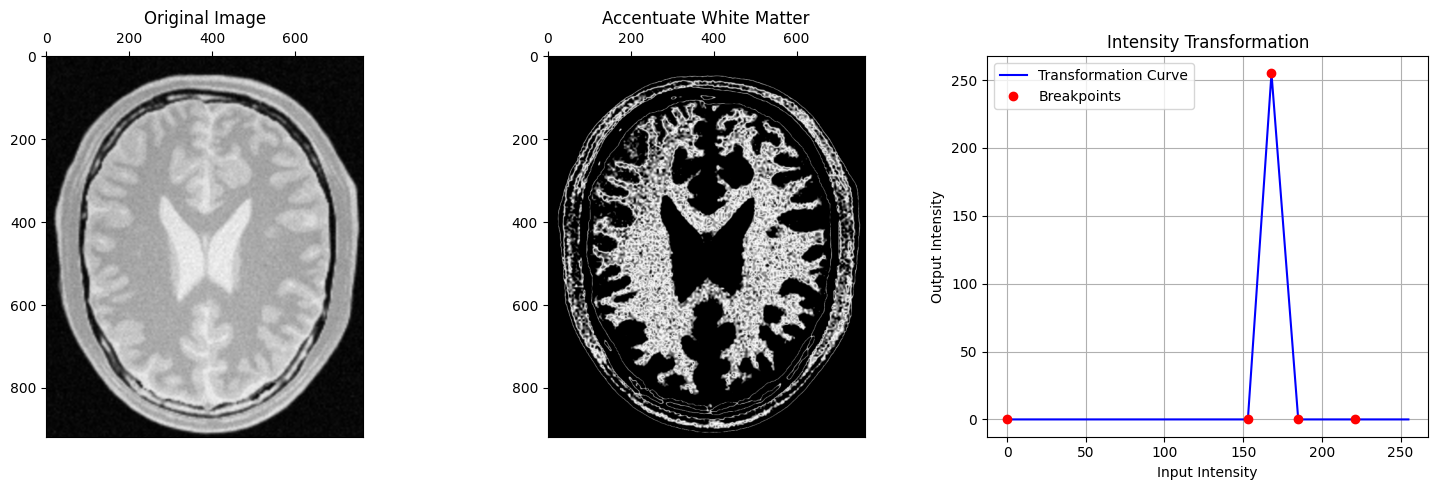

In [166]:
f = cv.imread("images/brain.png", cv.IMREAD_GRAYSCALE)
print(f)
breakpoints = [(0, 0), (153, 0), (168, 255), (185, 0), (221, 0)]

transformed_img, X, F = intensity_transform(f, breakpoints)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].xaxis.set_ticks_position('top') 

axes[1].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Accentuate White Matter")
axes[1].xaxis.set_ticks_position('top') 

axes[2].plot(X, F, color='blue', label='Transformation Curve')
x_coords, y_coords = zip(*breakpoints)
axes[2].plot(x_coords, y_coords, 'ro', label='Breakpoints') 
axes[2].set_title("Intensity Transformation")
axes[2].set_xlabel("Input Intensity")
axes[2].set_ylabel("Output Intensity")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

[[ 2  4  6 ... 10 12 11]
 [ 4  5  7 ... 10 11 11]
 [ 6  7  8 ...  9 10 10]
 ...
 [ 8  9  9 ...  4  4  4]
 [ 8  9  9 ...  4  4  4]
 [ 9  9  9 ...  4  4  4]]


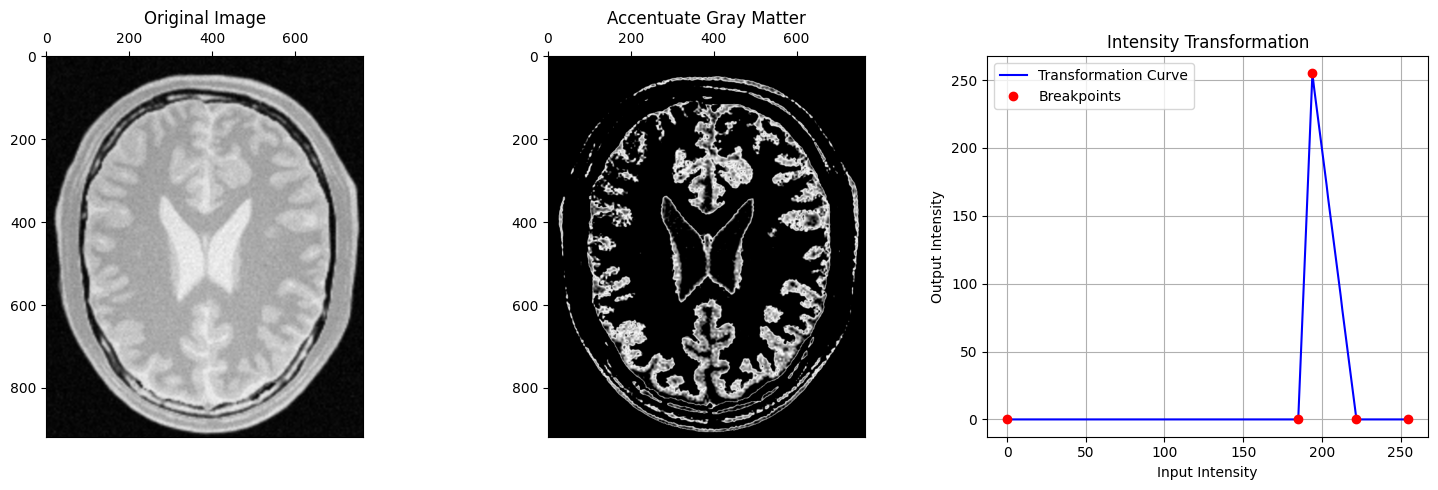

In [167]:
f = cv.imread("images/brain.png", cv.IMREAD_GRAYSCALE)
print(f)
breakpoints = [(0, 0), (185, 0), (194, 255), (222, 0), (255, 0)]

transformed_img, X, F = intensity_transform(f, breakpoints)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(f, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Original Image")
axes[0].xaxis.set_ticks_position('top') 

axes[1].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Accentuate Gray Matter")
axes[1].xaxis.set_ticks_position('top') 

axes[2].plot(X, F, color='blue', label='Transformation Curve')
x_coords, y_coords = zip(*breakpoints)
axes[2].plot(x_coords, y_coords, 'ro', label='Breakpoints') 
axes[2].set_title("Intensity Transformation")
axes[2].set_xlabel("Input Intensity")
axes[2].set_ylabel("Output Intensity")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

### Interpretation of Question 2: Tissue Accentuation

To successfully accentuate specific tissues in the brain proton density image, I first plotted a flattened histogram to identify the distinct intensity clusters. 

In a proton density (PD) MRI slice, image intensity is dictated by water concentration. Therefore, the physical appearance of the tissues is inverted compared to their anatomical names:
* **White Matter:** Composed largely of fatty myelin, it has lower water content and yields a weaker signal. It appears darker on the PD scan. On the histogram, I identified this as the first major peak. I designed a triangular breakpoint filter ranging from 153 to 185, peaking at an intensity of **168**.
* **Gray Matter:** Contains more cell bodies and higher water content, yielding a stronger signal and appearing brighter. I identified this as the second peak on the histogram. I designed a triangular breakpoint filter ranging from 185 to 222, peaking at an intensity of **194**.

By applying these custom breakpoint coordinates to the `intensity_transform` function, the target matter is driven to 255 (white) while all other background and tissue values are suppressed to 0 (black).

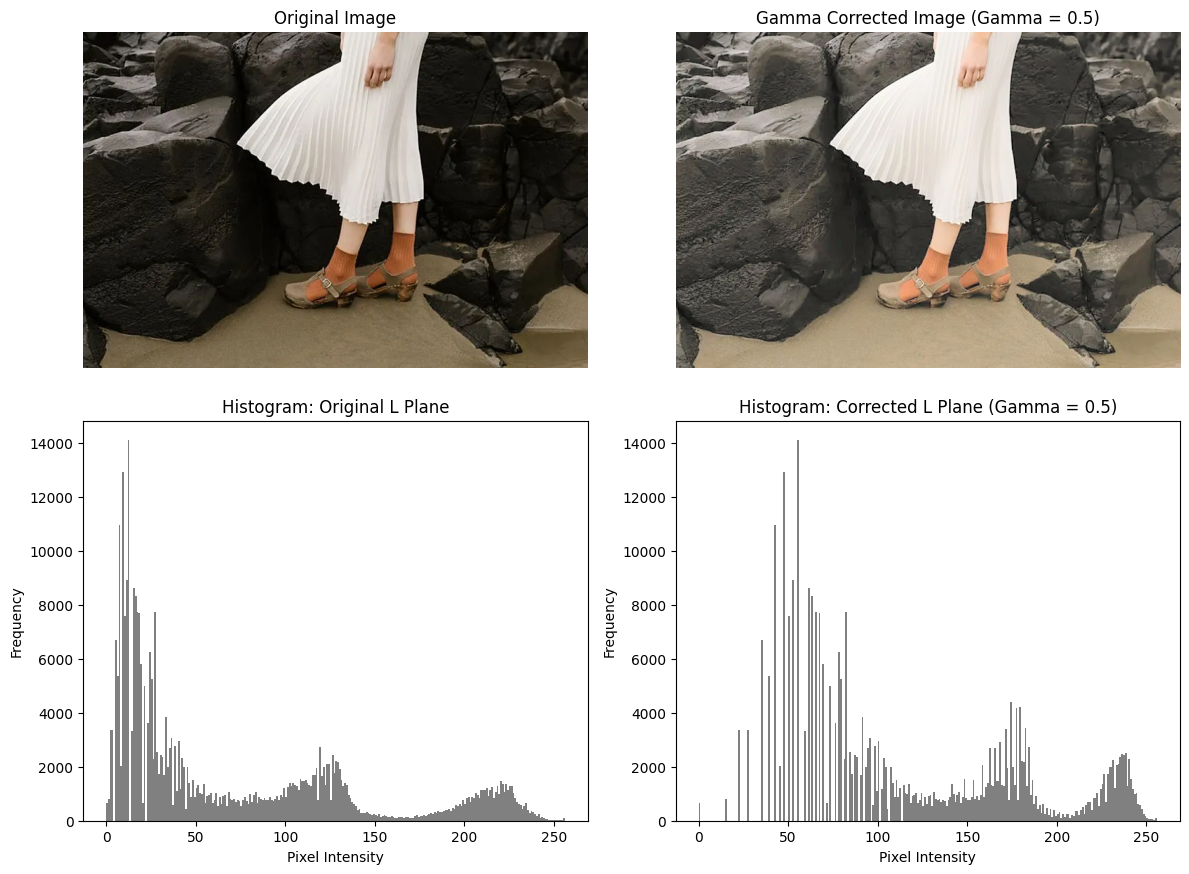

In [169]:
img_original = cv.imread(r"D:\Semester 5\CV\EN3160_Assignment_01\images\white.png", cv.IMREAD_COLOR)
f = cv.cvtColor(img_original,cv.COLOR_BGR2LAB)
L,a,b = cv.split(f)
gamma = 0.5
Lc = (((L/255.0)**(gamma))*255).astype(np.uint8)
img_lab = cv.merge([Lc,a,b])
img = cv.cvtColor(img_lab, cv.COLOR_LAB2RGB)

# Create a figure with 2 subplots side-by-side
# Create a figure with a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

# 1. Top-Left: Original Image
axes[0, 0].imshow(cv.cvtColor(img_original, cv.COLOR_BGR2RGB))
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')  # Hides the axes and border completely

# 2. Top-Right: Edited Image
axes[0, 1].imshow(img)
axes[0, 1].set_title(f"Gamma Corrected Image (Gamma = {gamma})")
axes[0, 1].axis('off')

# 3. Bottom-Left: Histogram for the Original L plane
axes[1, 0].hist(L.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 0].set_title("Histogram: Original L Plane")
axes[1, 0].set_xlabel("Pixel Intensity")
axes[1, 0].set_ylabel("Frequency")

# 4. Bottom-Right: Histogram for the Corrected L plane
axes[1, 1].hist(Lc.ravel(), bins=256, range=[0, 256], color='gray')
axes[1, 1].set_title(f"Histogram: Corrected L Plane (Gamma = {gamma})")
axes[1, 1].set_xlabel("Pixel Intensity")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### Interpretation of Question 3: Gamma Correction

The goal of this operation was to reveal the shadow details in the underexposed rocks without distorting the colors of the woman's skin or dress. 
To achieve this, the image was converted to the $L^{*}a^{*}b^{*}$ color space, separating the luminance ($L^{*}$) from the chrominance ($a^{*}$, $b^{*}$). 

A gamma correction of **$\gamma = 0.5$** was applied strictly to the normalized $L$ plane. Because $\gamma < 1$, this non-linear power-law transformation stretches the lower intensity values. 
As shown in the histograms, the heavy spike of dark pixels near 0 in the original $L$ plane is spread out towards the mid-tones in the corrected $L$ plane, effectively brightening the shadows while maintaining the original color data.